In [20]:
DATASET_ROOT = "/kaggle/input/datasets/hussamsyed/dataset-400/dataset_400"
MODEL_TYPE = "rgb"

In [18]:
import os
print(os.listdir("/kaggle/input"))
print(os.listdir("/kaggle/input/datasets/hussamsyed/dataset-400/dataset_400"))

['datasets', 'notebooks']
['sun_glare__20kmh__Red_to_Green', 'harsh_fog__0kmh__Green_to_Yellow', 'day_rain__20kmh__Yellow_to_Red', 'harsh_rain__60kmh__Red_to_Green', 'harsh_rain__60kmh__Yellow_to_Red', 'day_rain__60kmh__Yellow_to_Red', 'harsh_fog__20kmh__Green_to_Yellow', 'harsh_fog__20kmh__Red_to_Green', 'sun_glare__60kmh__Green_to_Yellow', 'harsh_fog__60kmh__Yellow_to_Red', 'harsh_rain__0kmh__Green_to_Yellow', 'sun_glare__20kmh__Green_to_Yellow', 'harsh_fog__60kmh__Red_to_Green', 'sun_glare__0kmh__Red_to_Green', 'day_rain__0kmh__Red_to_Green', 'harsh_rain__20kmh__Yellow_to_Red', 'day_rain__0kmh__Green_to_Yellow', 'harsh_fog__0kmh__Red_to_Green', 'harsh_rain__60kmh__Green_to_Yellow', 'harsh_rain__20kmh__Green_to_Yellow', 'harsh_fog__0kmh__Yellow_to_Red', 'day_rain__0kmh__Yellow_to_Red', 'harsh_fog__20kmh__Yellow_to_Red', 'sun_glare__60kmh__Yellow_to_Red', 'sun_glare__20kmh__Yellow_to_Red', 'sun_glare__0kmh__Yellow_to_Red', 'harsh_rain__0kmh__Yellow_to_Red', 'day_rain__20kmh__Green_to_

In [21]:
import os
import json
import random
from pathlib import Path

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
from torchvision import transforms

# =========================
# SET THESE
# =========================
DATASET_ROOT = "/kaggle/input/YOUR_DATASET_FOLDER"
MODEL_TYPE = "fusion"   # "rgb", "dvs", or "fusion"
EPOCHS = 25
BATCH_SIZE = 32
LR = 1e-3
IMAGE_SIZE = 64
DVS_SIZE = 64
NUM_WORKERS = 2
SEED = 42
PATIENCE = 5
OUTDIR = "./training_output"

LABEL_MAP = {"Red": 0, "Yellow": 1, "Green": 2}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

os.makedirs(OUTDIR, exist_ok=True)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# =========================
# FIND SAMPLES
# =========================
def find_samples(dataset_root):
    root = Path(dataset_root)
    samples = []

    for meta_path in root.rglob("meta.json"):
        sample_dir = meta_path.parent
        rgb_path = sample_dir / "roi_rgb.png"
        dvs_path = sample_dir / "dvs_sequence.npy"

        if not rgb_path.exists() or not dvs_path.exists():
            continue

        with open(meta_path, "r") as f:
            meta = json.load(f)

        if not meta.get("quality_ok", True):
            continue

        end_state = meta.get("end_state")
        if end_state not in LABEL_MAP:
            continue

        samples.append({
            "rgb_path": str(rgb_path),
            "dvs_path": str(dvs_path),
            "label_name": end_state,
            "label": LABEL_MAP[end_state],
            "weather_mode": meta.get("weather_mode", "unknown"),
            "speed_kmh": float(meta.get("speed_kmh", 0.0)),
            "traffic_light_id": int(meta.get("traffic_light_id", -1)),
        })

    if not samples:
        raise RuntimeError("No valid samples found. Check DATASET_ROOT.")
    return samples

samples = find_samples(DATASET_ROOT)
print("Accepted samples found:", len(samples))

# =========================
# SPLIT BY traffic_light_id
# =========================
def group_split_by_traffic_light_id(samples, seed=42, train_ratio=0.7, val_ratio=0.15):
    groups = {}
    for idx, s in enumerate(samples):
        gid = s["traffic_light_id"]
        groups.setdefault(gid, []).append(idx)

    group_ids = list(groups.keys())
    rng = random.Random(seed)
    rng.shuffle(group_ids)

    n_groups = len(group_ids)
    n_train = max(1, int(train_ratio * n_groups))
    n_val = max(1, int(val_ratio * n_groups))

    train_g = set(group_ids[:n_train])
    val_g = set(group_ids[n_train:n_train + n_val])
    test_g = set(group_ids[n_train + n_val:])

    train_idx, val_idx, test_idx = [], [], []
    for gid, idxs in groups.items():
        if gid in train_g:
            train_idx.extend(idxs)
        elif gid in val_g:
            val_idx.extend(idxs)
        else:
            test_idx.extend(idxs)

    if not val_idx or not test_idx:
        all_idx = list(range(len(samples)))
        rng.shuffle(all_idx)
        n_total = len(all_idx)
        n_train = max(1, int(0.7 * n_total))
        n_val = max(1, int(0.15 * n_total))
        train_idx = all_idx[:n_train]
        val_idx = all_idx[n_train:n_train + n_val]
        test_idx = all_idx[n_train + n_val:]

    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = group_split_by_traffic_light_id(samples, seed=SEED)
print(f"Split sizes: train={len(train_idx)} val={len(val_idx)} test={len(test_idx)}")

# =========================
# DATASET
# =========================
class TrafficLightDataset(Dataset):
    def __init__(self, samples, indices, model_type="fusion", image_size=64, dvs_size=64, train=True):
        self.samples = samples
        self.indices = indices
        self.model_type = model_type
        self.image_size = image_size
        self.dvs_size = dvs_size

        if train:
            self.rgb_tf = transforms.Compose([
                transforms.Resize((image_size, image_size)),
                transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
                transforms.ToTensor(),
            ])
        else:
            self.rgb_tf = transforms.Compose([
                transforms.Resize((image_size, image_size)),
                transforms.ToTensor(),
            ])

    def __len__(self):
        return len(self.indices)

    def _load_rgb(self, path):
        img = Image.open(path).convert("RGB")
        return self.rgb_tf(img)

    def _load_dvs(self, path):
        arr = np.load(path)  # [T, 2, H, W]
        x = torch.from_numpy(arr).float()
        x = torch.log1p(x)
        x = F.interpolate(x, size=(self.dvs_size, self.dvs_size), mode="bilinear", align_corners=False)
        denom = x.amax(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
        x = x / denom
        return x

    def __getitem__(self, i):
        idx = self.indices[i]
        item = self.samples[idx]
        y = torch.tensor(item["label"], dtype=torch.long)

        out = {
            "label": y,
            "weather_mode": item["weather_mode"],
            "speed_kmh": item["speed_kmh"],
            "traffic_light_id": item["traffic_light_id"],
        }

        if self.model_type in ["rgb", "fusion"]:
            out["rgb"] = self._load_rgb(item["rgb_path"])
        if self.model_type in ["dvs", "fusion"]:
            out["dvs"] = self._load_dvs(item["dvs_path"])

        return out

def collate_fn(batch):
    out = {}
    for k in batch[0].keys():
        if k in ["weather_mode", "speed_kmh", "traffic_light_id"]:
            out[k] = [b[k] for b in batch]
        else:
            out[k] = torch.stack([b[k] for b in batch])
    return out

train_ds = TrafficLightDataset(samples, train_idx, MODEL_TYPE, IMAGE_SIZE, DVS_SIZE, train=True)
val_ds   = TrafficLightDataset(samples, val_idx, MODEL_TYPE, IMAGE_SIZE, DVS_SIZE, train=False)
test_ds  = TrafficLightDataset(samples, test_idx, MODEL_TYPE, IMAGE_SIZE, DVS_SIZE, train=False)

# weighted sampler by (label, weather_mode)
def make_weighted_sampler(samples, train_indices):
    counts = {}
    for idx in train_indices:
        s = samples[idx]
        key = (s["label_name"], s["weather_mode"])
        counts[key] = counts.get(key, 0) + 1

    weights = []
    for idx in train_indices:
        s = samples[idx]
        key = (s["label_name"], s["weather_mode"])
        weights.append(1.0 / counts[key])

    return WeightedRandomSampler(torch.DoubleTensor(weights), num_samples=len(weights), replacement=True)

sampler = make_weighted_sampler(samples, train_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)

# =========================
# MODELS
# =========================
class RGBNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.net = torchvision.models.resnet18(weights=None)
        self.net.fc = nn.Linear(self.net.fc.in_features, num_classes)

    def forward(self, x):
        return self.net(x)

class DVSNet(nn.Module):
    def __init__(self, time_bins=5, num_classes=3):
        super().__init__()
        in_ch = time_bins * 2
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        b, t, c, h, w = x.shape
        x = x.view(b, t * c, h, w)
        x = self.features(x).flatten(1)
        return self.fc(x)

class FusionNet(nn.Module):
    def __init__(self, time_bins=5, num_classes=3):
        super().__init__()
        self.rgb = torchvision.models.resnet18(weights=None)
        self.rgb.fc = nn.Identity()

        in_ch = time_bins * 2
        self.dvs = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.head = nn.Sequential(
            nn.Linear(512 + 128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(256, num_classes),
        )

    def forward(self, rgb, dvs):
        rgb_feat = self.rgb(rgb)
        b, t, c, h, w = dvs.shape
        dvs = dvs.view(b, t * c, h, w)
        dvs_feat = self.dvs(dvs).flatten(1)
        x = torch.cat([rgb_feat, dvs_feat], dim=1)
        return self.head(x)

def build_model(model_type):
    if model_type == "rgb":
        return RGBNet()
    if model_type == "dvs":
        return DVSNet()
    if model_type == "fusion":
        return FusionNet()
    raise ValueError(model_type)

model = build_model(MODEL_TYPE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

# =========================
# TRAINING UTILS
# =========================
def accuracy(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

def forward_batch(model, batch, device, model_type):
    y = batch["label"].to(device)
    if model_type == "rgb":
        logits = model(batch["rgb"].to(device))
    elif model_type == "dvs":
        logits = model(batch["dvs"].to(device))
    else:
        logits = model(batch["rgb"].to(device), batch["dvs"].to(device))
    return logits, y

def run_epoch(model, loader, device, model_type, optimizer=None):
    train = optimizer is not None
    model.train(train)

    total_loss = 0.0
    total_acc = 0.0
    total_n = 0

    for batch in loader:
        logits, y = forward_batch(model, batch, device, model_type)
        loss = criterion(logits, y)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy(logits.detach(), y) * bs
        total_n += bs

    return total_loss / total_n, total_acc / total_n

def confusion_matrix(model, loader, device, model_type, num_classes=3):
    model.eval()
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    with torch.no_grad():
        for batch in loader:
            logits, y = forward_batch(model, batch, device, model_type)
            preds = logits.argmax(dim=1).cpu().numpy()
            ys = y.cpu().numpy()
            for t, p in zip(ys, preds):
                cm[t, p] += 1
    return cm

def eval_by_key(model, loader, device, model_type, key_name):
    model.eval()
    out = {}
    with torch.no_grad():
        for batch in loader:
            logits, y = forward_batch(model, batch, device, model_type)
            preds = logits.argmax(dim=1).cpu().numpy()
            ys = y.cpu().numpy()
            keys = batch[key_name]
            for p, t, key in zip(preds, ys, keys):
                out.setdefault(str(key), {"correct": 0, "total": 0})
                out[str(key)]["correct"] += int(p == t)
                out[str(key)]["total"] += 1
    return {k: v["correct"] / max(v["total"], 1) for k, v in out.items()}

# =========================
# TRAIN
# =========================
best_val_acc = -1.0
best_epoch = -1
patience_counter = 0
best_path = os.path.join(OUTDIR, f"best_{MODEL_TYPE}.pt")
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, device, MODEL_TYPE, optimizer=optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, device, MODEL_TYPE, optimizer=None)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        patience_counter = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "best_val_acc": best_val_acc,
                "best_epoch": best_epoch,
                "model_type": MODEL_TYPE,
            },
            best_path,
        )
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

# =========================
# TEST
# =========================
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])

test_loss, test_acc = run_epoch(model, test_loader, device, MODEL_TYPE, optimizer=None)
cm = confusion_matrix(model, test_loader, device, MODEL_TYPE)
weather_acc = eval_by_key(model, test_loader, device, MODEL_TYPE, "weather_mode")
speed_acc = eval_by_key(model, test_loader, device, MODEL_TYPE, "speed_kmh")

summary = {
    "model": MODEL_TYPE,
    "dataset_root": DATASET_ROOT,
    "n_total": len(samples),
    "n_train": len(train_idx),
    "n_val": len(val_idx),
    "n_test": len(test_idx),
    "best_val_acc": best_val_acc,
    "best_epoch": best_epoch,
    "test_loss": test_loss,
    "test_acc": test_acc,
    "weather_acc": weather_acc,
    "speed_acc": speed_acc,
    "confusion_matrix": cm.tolist(),
    "labels": INV_LABEL_MAP,
    "history": history,
}

with open(os.path.join(OUTDIR, f"summary_{MODEL_TYPE}.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("\nBest validation accuracy:", round(best_val_acc, 4))
print("Test accuracy:", round(test_acc, 4))

print("\nPer-weather accuracy:")
for k, v in sorted(weather_acc.items()):
    print(f"  {k}: {v:.4f}")

print("\nPer-speed accuracy:")
for k, v in sorted(speed_acc.items(), key=lambda x: float(x[0])):
    print(f"  {k}: {v:.4f}")

print("\nConfusion matrix (rows=true, cols=pred):")
print(cm)

print(f"\nSaved checkpoint: {best_path}")
print(f"Saved summary: {os.path.join(OUTDIR, f'summary_{MODEL_TYPE}.json')}")

Device: cpu


RuntimeError: No valid samples found. Check DATASET_ROOT.

In [24]:
import os

for root, dirs, files in os.walk("/kaggle/input/datasets/hussamsyed/dataset-400/dataset_400"):
    print("ROOT:", root)
    print("DIRS:", dirs[:5])
    print("FILES:", files[:5])
    print("-" * 60)
    if root.count("/") > 6:
        break

ROOT: /kaggle/input/datasets/hussamsyed/dataset-400/dataset_400
DIRS: ['sun_glare__20kmh__Red_to_Green', 'harsh_fog__0kmh__Green_to_Yellow', 'day_rain__20kmh__Yellow_to_Red', 'harsh_rain__60kmh__Red_to_Green', 'harsh_rain__60kmh__Yellow_to_Red']
FILES: []
------------------------------------------------------------
ROOT: /kaggle/input/datasets/hussamsyed/dataset-400/dataset_400/sun_glare__20kmh__Red_to_Green
DIRS: ['sample_0308', 'sample_0306', 'sample_0304', 'sample_0303', 'sample_0307']
FILES: []
------------------------------------------------------------


In [25]:
from pathlib import Path

paths = list(Path("/kaggle/input/datasets/hussamsyed/dataset-400/dataset_400").rglob("meta.json"))
print("meta count:", len(paths))
for p in paths[:10]:
    print(p)

meta count: 357
/kaggle/input/datasets/hussamsyed/dataset-400/dataset_400/sun_glare__20kmh__Red_to_Green/sample_0308/meta.json
/kaggle/input/datasets/hussamsyed/dataset-400/dataset_400/sun_glare__20kmh__Red_to_Green/sample_0306/meta.json
/kaggle/input/datasets/hussamsyed/dataset-400/dataset_400/sun_glare__20kmh__Red_to_Green/sample_0304/meta.json
/kaggle/input/datasets/hussamsyed/dataset-400/dataset_400/sun_glare__20kmh__Red_to_Green/sample_0303/meta.json
/kaggle/input/datasets/hussamsyed/dataset-400/dataset_400/sun_glare__20kmh__Red_to_Green/sample_0307/meta.json
/kaggle/input/datasets/hussamsyed/dataset-400/dataset_400/sun_glare__20kmh__Red_to_Green/sample_0302/meta.json
/kaggle/input/datasets/hussamsyed/dataset-400/dataset_400/sun_glare__20kmh__Red_to_Green/sample_0301/meta.json
/kaggle/input/datasets/hussamsyed/dataset-400/dataset_400/sun_glare__20kmh__Red_to_Green/sample_0305/meta.json
/kaggle/input/datasets/hussamsyed/dataset-400/dataset_400/sun_glare__20kmh__Red_to_Green/sample_

In [1]:
DATASET_ROOT = "/kaggle/input/datasets/hussamsyed/dataset-400/dataset_400"
MODEL_TYPE = "rgb"   # then later try "dvs" and "fusion"
EPOCHS = 25
BATCH_SIZE = 32
LR = 1e-3
IMAGE_SIZE = 64
DVS_SIZE = 64
NUM_WORKERS = 2
SEED = 42
PATIENCE = 5
OUTDIR = "./training_output"

In [2]:
from pathlib import Path
import json

root = Path("/kaggle/input/datasets/hussamsyed/dataset-400/dataset_400")
meta_paths = list(root.rglob("meta.json"))
print("meta count:", len(meta_paths))

p = meta_paths[0]
print("sample dir:", p.parent)
print("files:", [x.name for x in p.parent.iterdir()])

with open(p, "r") as f:
    meta = json.load(f)
print("quality_ok:", meta.get("quality_ok"))
print("end_state:", meta.get("end_state"))

meta count: 357
sample dir: /kaggle/input/datasets/hussamsyed/dataset-400/dataset_400/sun_glare__20kmh__Red_to_Green/sample_0308
files: ['roi_rgb.png', 'dvs_sequence.npy', 'meta.json']
quality_ok: True
end_state: Green


meta count: 357
sample dir: /kaggle/input/datasets/hussamsyed/dataset-400/dataset_400/sun_glare__20kmh__Red_to_Green/sample_0308
files: ['roi_rgb.png', 'dvs_sequence.npy', 'meta.json']
quality_ok: True
end_state: Green


In [1]:
import os
import json
import random
from pathlib import Path

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
from torchvision import transforms

# =========================
# SET THESE
# =========================
DATASET_ROOT = "/kaggle/input/datasets/hussamsyed/dataset-400/dataset_400"
MODEL_TYPE = "fusion"   # "rgb", "dvs", or "fusion"
EPOCHS = 25
BATCH_SIZE = 32
LR = 1e-3
IMAGE_SIZE = 64
DVS_SIZE = 64
NUM_WORKERS = 2
SEED = 42
PATIENCE = 5
OUTDIR = "./training_output"

LABEL_MAP = {"Red": 0, "Yellow": 1, "Green": 2}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

os.makedirs(OUTDIR, exist_ok=True)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# =========================
# FIND SAMPLES
# =========================
def find_samples(dataset_root):
    root = Path(dataset_root)
    samples = []

    for meta_path in root.rglob("meta.json"):
        sample_dir = meta_path.parent
        rgb_path = sample_dir / "roi_rgb.png"
        dvs_path = sample_dir / "dvs_sequence.npy"

        if not rgb_path.exists() or not dvs_path.exists():
            continue

        with open(meta_path, "r") as f:
            meta = json.load(f)

        if not meta.get("quality_ok", True):
            continue

        end_state = meta.get("end_state")
        if end_state not in LABEL_MAP:
            continue

        samples.append({
            "rgb_path": str(rgb_path),
            "dvs_path": str(dvs_path),
            "label_name": end_state,
            "label": LABEL_MAP[end_state],
            "weather_mode": meta.get("weather_mode", "unknown"),
            "speed_kmh": float(meta.get("speed_kmh", 0.0)),
            "traffic_light_id": int(meta.get("traffic_light_id", -1)),
        })

    if not samples:
        raise RuntimeError("No valid samples found. Check DATASET_ROOT.")
    return samples

samples = find_samples(DATASET_ROOT)
print("Accepted samples found:", len(samples))

# =========================
# SPLIT BY traffic_light_id
# =========================
def group_split_by_traffic_light_id(samples, seed=42, train_ratio=0.7, val_ratio=0.15):
    groups = {}
    for idx, s in enumerate(samples):
        gid = s["traffic_light_id"]
        groups.setdefault(gid, []).append(idx)

    group_ids = list(groups.keys())
    rng = random.Random(seed)
    rng.shuffle(group_ids)

    n_groups = len(group_ids)
    n_train = max(1, int(train_ratio * n_groups))
    n_val = max(1, int(val_ratio * n_groups))

    train_g = set(group_ids[:n_train])
    val_g = set(group_ids[n_train:n_train + n_val])
    test_g = set(group_ids[n_train + n_val:])

    train_idx, val_idx, test_idx = [], [], []
    for gid, idxs in groups.items():
        if gid in train_g:
            train_idx.extend(idxs)
        elif gid in val_g:
            val_idx.extend(idxs)
        else:
            test_idx.extend(idxs)

    if not val_idx or not test_idx:
        all_idx = list(range(len(samples)))
        rng.shuffle(all_idx)
        n_total = len(all_idx)
        n_train = max(1, int(0.7 * n_total))
        n_val = max(1, int(0.15 * n_total))
        train_idx = all_idx[:n_train]
        val_idx = all_idx[n_train:n_train + n_val]
        test_idx = all_idx[n_train + n_val:]

    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = group_split_by_traffic_light_id(samples, seed=SEED)
print(f"Split sizes: train={len(train_idx)} val={len(val_idx)} test={len(test_idx)}")

# =========================
# DATASET
# =========================
class TrafficLightDataset(Dataset):
    def __init__(self, samples, indices, model_type="fusion", image_size=64, dvs_size=64, train=True):
        self.samples = samples
        self.indices = indices
        self.model_type = model_type
        self.image_size = image_size
        self.dvs_size = dvs_size

        if train:
            self.rgb_tf = transforms.Compose([
                transforms.Resize((image_size, image_size)),
                transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
                transforms.ToTensor(),
            ])
        else:
            self.rgb_tf = transforms.Compose([
                transforms.Resize((image_size, image_size)),
                transforms.ToTensor(),
            ])

    def __len__(self):
        return len(self.indices)

    def _load_rgb(self, path):
        img = Image.open(path).convert("RGB")
        return self.rgb_tf(img)

    def _load_dvs(self, path):
        arr = np.load(path)  # [T, 2, H, W]
        x = torch.from_numpy(arr).float()
        x = torch.log1p(x)
        x = F.interpolate(x, size=(self.dvs_size, self.dvs_size), mode="bilinear", align_corners=False)
        denom = x.amax(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
        x = x / denom
        return x

    def __getitem__(self, i):
        idx = self.indices[i]
        item = self.samples[idx]
        y = torch.tensor(item["label"], dtype=torch.long)

        out = {
            "label": y,
            "weather_mode": item["weather_mode"],
            "speed_kmh": item["speed_kmh"],
            "traffic_light_id": item["traffic_light_id"],
        }

        if self.model_type in ["rgb", "fusion"]:
            out["rgb"] = self._load_rgb(item["rgb_path"])
        if self.model_type in ["dvs", "fusion"]:
            out["dvs"] = self._load_dvs(item["dvs_path"])

        return out

def collate_fn(batch):
    out = {}
    for k in batch[0].keys():
        if k in ["weather_mode", "speed_kmh", "traffic_light_id"]:
            out[k] = [b[k] for b in batch]
        else:
            out[k] = torch.stack([b[k] for b in batch])
    return out

train_ds = TrafficLightDataset(samples, train_idx, MODEL_TYPE, IMAGE_SIZE, DVS_SIZE, train=True)
val_ds   = TrafficLightDataset(samples, val_idx, MODEL_TYPE, IMAGE_SIZE, DVS_SIZE, train=False)
test_ds  = TrafficLightDataset(samples, test_idx, MODEL_TYPE, IMAGE_SIZE, DVS_SIZE, train=False)

# weighted sampler by (label, weather_mode)
def make_weighted_sampler(samples, train_indices):
    counts = {}
    for idx in train_indices:
        s = samples[idx]
        key = (s["label_name"], s["weather_mode"])
        counts[key] = counts.get(key, 0) + 1

    weights = []
    for idx in train_indices:
        s = samples[idx]
        key = (s["label_name"], s["weather_mode"])
        weights.append(1.0 / counts[key])

    return WeightedRandomSampler(torch.DoubleTensor(weights), num_samples=len(weights), replacement=True)

sampler = make_weighted_sampler(samples, train_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)

# =========================
# MODELS
# =========================
class RGBNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.net = torchvision.models.resnet18(weights=None)
        self.net.fc = nn.Linear(self.net.fc.in_features, num_classes)

    def forward(self, x):
        return self.net(x)

class DVSNet(nn.Module):
    def __init__(self, time_bins=5, num_classes=3):
        super().__init__()
        in_ch = time_bins * 2
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        b, t, c, h, w = x.shape
        x = x.view(b, t * c, h, w)
        x = self.features(x).flatten(1)
        return self.fc(x)

class FusionNet(nn.Module):
    def __init__(self, time_bins=5, num_classes=3):
        super().__init__()
        self.rgb = torchvision.models.resnet18(weights=None)
        self.rgb.fc = nn.Identity()

        in_ch = time_bins * 2
        self.dvs = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.head = nn.Sequential(
            nn.Linear(512 + 128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(256, num_classes),
        )

    def forward(self, rgb, dvs):
        rgb_feat = self.rgb(rgb)
        b, t, c, h, w = dvs.shape
        dvs = dvs.view(b, t * c, h, w)
        dvs_feat = self.dvs(dvs).flatten(1)
        x = torch.cat([rgb_feat, dvs_feat], dim=1)
        return self.head(x)

def build_model(model_type):
    if model_type == "rgb":
        return RGBNet()
    if model_type == "dvs":
        return DVSNet()
    if model_type == "fusion":
        return FusionNet()
    raise ValueError(model_type)

model = build_model(MODEL_TYPE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

# =========================
# TRAINING UTILS
# =========================
def accuracy(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

def forward_batch(model, batch, device, model_type):
    y = batch["label"].to(device)
    if model_type == "rgb":
        logits = model(batch["rgb"].to(device))
    elif model_type == "dvs":
        logits = model(batch["dvs"].to(device))
    else:
        logits = model(batch["rgb"].to(device), batch["dvs"].to(device))
    return logits, y

def run_epoch(model, loader, device, model_type, optimizer=None):
    train = optimizer is not None
    model.train(train)

    total_loss = 0.0
    total_acc = 0.0
    total_n = 0

    for batch in loader:
        logits, y = forward_batch(model, batch, device, model_type)
        loss = criterion(logits, y)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy(logits.detach(), y) * bs
        total_n += bs

    return total_loss / total_n, total_acc / total_n

def confusion_matrix(model, loader, device, model_type, num_classes=3):
    model.eval()
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    with torch.no_grad():
        for batch in loader:
            logits, y = forward_batch(model, batch, device, model_type)
            preds = logits.argmax(dim=1).cpu().numpy()
            ys = y.cpu().numpy()
            for t, p in zip(ys, preds):
                cm[t, p] += 1
    return cm

def eval_by_key(model, loader, device, model_type, key_name):
    model.eval()
    out = {}
    with torch.no_grad():
        for batch in loader:
            logits, y = forward_batch(model, batch, device, model_type)
            preds = logits.argmax(dim=1).cpu().numpy()
            ys = y.cpu().numpy()
            keys = batch[key_name]
            for p, t, key in zip(preds, ys, keys):
                out.setdefault(str(key), {"correct": 0, "total": 0})
                out[str(key)]["correct"] += int(p == t)
                out[str(key)]["total"] += 1
    return {k: v["correct"] / max(v["total"], 1) for k, v in out.items()}

# =========================
# TRAIN
# =========================
best_val_acc = -1.0
best_epoch = -1
patience_counter = 0
best_path = os.path.join(OUTDIR, f"best_{MODEL_TYPE}.pt")
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, device, MODEL_TYPE, optimizer=optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, device, MODEL_TYPE, optimizer=None)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        patience_counter = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "best_val_acc": best_val_acc,
                "best_epoch": best_epoch,
                "model_type": MODEL_TYPE,
            },
            best_path,
        )
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

# =========================
# TEST
# =========================
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])

test_loss, test_acc = run_epoch(model, test_loader, device, MODEL_TYPE, optimizer=None)
cm = confusion_matrix(model, test_loader, device, MODEL_TYPE)
weather_acc = eval_by_key(model, test_loader, device, MODEL_TYPE, "weather_mode")
speed_acc = eval_by_key(model, test_loader, device, MODEL_TYPE, "speed_kmh")

summary = {
    "model": MODEL_TYPE,
    "dataset_root": DATASET_ROOT,
    "n_total": len(samples),
    "n_train": len(train_idx),
    "n_val": len(val_idx),
    "n_test": len(test_idx),
    "best_val_acc": best_val_acc,
    "best_epoch": best_epoch,
    "test_loss": test_loss,
    "test_acc": test_acc,
    "weather_acc": weather_acc,
    "speed_acc": speed_acc,
    "confusion_matrix": cm.tolist(),
    "labels": INV_LABEL_MAP,
    "history": history,
}

with open(os.path.join(OUTDIR, f"summary_{MODEL_TYPE}.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("\nBest validation accuracy:", round(best_val_acc, 4))
print("Test accuracy:", round(test_acc, 4))

print("\nPer-weather accuracy:")
for k, v in sorted(weather_acc.items()):
    print(f"  {k}: {v:.4f}")

print("\nPer-speed accuracy:")
for k, v in sorted(speed_acc.items(), key=lambda x: float(x[0])):
    print(f"  {k}: {v:.4f}")

print("\nConfusion matrix (rows=true, cols=pred):")
print(cm)

print(f"\nSaved checkpoint: {best_path}")
print(f"Saved summary: {os.path.join(OUTDIR, f'summary_{MODEL_TYPE}.json')}")

Device: cuda
Accepted samples found: 357
Split sizes: train=259 val=36 test=62
Epoch 01 | train_loss=0.3914 train_acc=0.8456 | val_loss=0.0766 val_acc=1.0000
Epoch 02 | train_loss=0.1052 train_acc=0.9653 | val_loss=2.7691 val_acc=0.3333
Epoch 03 | train_loss=0.2333 train_acc=0.8958 | val_loss=1.1166 val_acc=0.8056
Epoch 04 | train_loss=0.0904 train_acc=0.9653 | val_loss=0.6530 val_acc=0.7500
Epoch 05 | train_loss=0.1219 train_acc=0.9691 | val_loss=0.0104 val_acc=1.0000
Epoch 06 | train_loss=0.0928 train_acc=0.9923 | val_loss=1.0679 val_acc=0.8333
Early stopping at epoch 6

Best validation accuracy: 1.0
Test accuracy: 1.0

Per-weather accuracy:
  day_rain: 1.0000
  harsh_rain: 1.0000
  sun_glare: 1.0000

Per-speed accuracy:
  0.0: 1.0000
  20.0: 1.0000
  60.0: 1.0000

Confusion matrix (rows=true, cols=pred):
[[15  0  0]
 [ 0 20  0]
 [ 0  0 27]]

Saved checkpoint: ./training_output/best_fusion.pt
Saved summary: ./training_output/summary_fusion.json


In [1]:
import os
import json
import random
from pathlib import Path

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision
from torchvision import transforms

# =========================
# SET THESE
# =========================
DATASET_ROOT = "/kaggle/input/datasets/hussamsyed/dataset-400/dataset_400"
MODELS_TO_RUN = ["rgb", "dvs", "fusion"]
EPOCHS = 25
BATCH_SIZE = 32
LR = 1e-3
IMAGE_SIZE = 64
DVS_SIZE = 64
NUM_WORKERS = 2
SEED = 42
PATIENCE = 5
OUTDIR = "./training_output"

LABEL_MAP = {"Red": 0, "Yellow": 1, "Green": 2}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

os.makedirs(OUTDIR, exist_ok=True)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# =========================
# FIND SAMPLES
# =========================
def find_samples(dataset_root):
    root = Path(dataset_root)
    samples = []

    for meta_path in root.rglob("meta.json"):
        sample_dir = meta_path.parent
        rgb_path = sample_dir / "roi_rgb.png"
        dvs_path = sample_dir / "dvs_sequence.npy"

        if not rgb_path.exists() or not dvs_path.exists():
            continue

        with open(meta_path, "r") as f:
            meta = json.load(f)

        if not meta.get("quality_ok", True):
            continue

        end_state = meta.get("end_state")
        if end_state not in LABEL_MAP:
            continue

        samples.append({
            "rgb_path": str(rgb_path),
            "dvs_path": str(dvs_path),
            "label_name": end_state,
            "label": LABEL_MAP[end_state],
            "weather_mode": meta.get("weather_mode", "unknown"),
            "speed_kmh": float(meta.get("speed_kmh", 0.0)),
            "traffic_light_id": int(meta.get("traffic_light_id", -1)),
        })

    if not samples:
        raise RuntimeError("No valid samples found. Check DATASET_ROOT.")
    return samples

samples = find_samples(DATASET_ROOT)
print("Accepted samples found:", len(samples))

# =========================
# SPLIT BY traffic_light_id
# =========================
def group_split_by_traffic_light_id(samples, seed=42, train_ratio=0.7, val_ratio=0.15):
    groups = {}
    for idx, s in enumerate(samples):
        gid = s["traffic_light_id"]
        groups.setdefault(gid, []).append(idx)

    group_ids = list(groups.keys())
    rng = random.Random(seed)
    rng.shuffle(group_ids)

    n_groups = len(group_ids)
    n_train = max(1, int(train_ratio * n_groups))
    n_val = max(1, int(val_ratio * n_groups))

    train_g = set(group_ids[:n_train])
    val_g = set(group_ids[n_train:n_train + n_val])
    test_g = set(group_ids[n_train + n_val:])

    train_idx, val_idx, test_idx = [], [], []
    for gid, idxs in groups.items():
        if gid in train_g:
            train_idx.extend(idxs)
        elif gid in val_g:
            val_idx.extend(idxs)
        else:
            test_idx.extend(idxs)

    if not val_idx or not test_idx:
        all_idx = list(range(len(samples)))
        rng.shuffle(all_idx)
        n_total = len(all_idx)
        n_train = max(1, int(0.7 * n_total))
        n_val = max(1, int(0.15 * n_total))
        train_idx = all_idx[:n_train]
        val_idx = all_idx[n_train:n_train + n_val]
        test_idx = all_idx[n_train + n_val:]

    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = group_split_by_traffic_light_id(samples, seed=SEED)
print(f"Split sizes: train={len(train_idx)} val={len(val_idx)} test={len(test_idx)}")

# =========================
# DATASET
# =========================
class TrafficLightDataset(Dataset):
    def __init__(self, samples, indices, model_type="fusion", image_size=64, dvs_size=64, train=True):
        self.samples = samples
        self.indices = indices
        self.model_type = model_type
        self.image_size = image_size
        self.dvs_size = dvs_size

        if train:
            self.rgb_tf = transforms.Compose([
                transforms.Resize((image_size, image_size)),
                transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
                transforms.ToTensor(),
            ])
        else:
            self.rgb_tf = transforms.Compose([
                transforms.Resize((image_size, image_size)),
                transforms.ToTensor(),
            ])

    def __len__(self):
        return len(self.indices)

    def _load_rgb(self, path):
        img = Image.open(path).convert("RGB")
        return self.rgb_tf(img)

    def _load_dvs(self, path):
        arr = np.load(path)  # [T, 2, H, W]
        x = torch.from_numpy(arr).float()
        x = torch.log1p(x)
        x = F.interpolate(x, size=(self.dvs_size, self.dvs_size), mode="bilinear", align_corners=False)
        denom = x.amax(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
        x = x / denom
        return x

    def __getitem__(self, i):
        idx = self.indices[i]
        item = self.samples[idx]
        y = torch.tensor(item["label"], dtype=torch.long)

        out = {
            "label": y,
            "weather_mode": item["weather_mode"],
            "speed_kmh": item["speed_kmh"],
            "traffic_light_id": item["traffic_light_id"],
        }

        if self.model_type in ["rgb", "fusion"]:
            out["rgb"] = self._load_rgb(item["rgb_path"])
        if self.model_type in ["dvs", "fusion"]:
            out["dvs"] = self._load_dvs(item["dvs_path"])

        return out

def collate_fn(batch):
    out = {}
    for k in batch[0].keys():
        if k in ["weather_mode", "speed_kmh", "traffic_light_id"]:
            out[k] = [b[k] for b in batch]
        else:
            out[k] = torch.stack([b[k] for b in batch])
    return out

def make_weighted_sampler(samples, train_indices):
    counts = {}
    for idx in train_indices:
        s = samples[idx]
        key = (s["label_name"], s["weather_mode"])
        counts[key] = counts.get(key, 0) + 1

    weights = []
    for idx in train_indices:
        s = samples[idx]
        key = (s["label_name"], s["weather_mode"])
        weights.append(1.0 / counts[key])

    return WeightedRandomSampler(torch.DoubleTensor(weights), num_samples=len(weights), replacement=True)

sampler = make_weighted_sampler(samples, train_idx)

# =========================
# MODELS
# =========================
class RGBNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.net = torchvision.models.resnet18(weights=None)
        self.net.fc = nn.Linear(self.net.fc.in_features, num_classes)

    def forward(self, x):
        return self.net(x)

class DVSNet(nn.Module):
    def __init__(self, time_bins=5, num_classes=3):
        super().__init__()
        in_ch = time_bins * 2
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        b, t, c, h, w = x.shape
        x = x.view(b, t * c, h, w)
        x = self.features(x).flatten(1)
        return self.fc(x)

class FusionNet(nn.Module):
    def __init__(self, time_bins=5, num_classes=3):
        super().__init__()
        self.rgb = torchvision.models.resnet18(weights=None)
        self.rgb.fc = nn.Identity()

        in_ch = time_bins * 2
        self.dvs = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.head = nn.Sequential(
            nn.Linear(512 + 128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(256, num_classes),
        )

    def forward(self, rgb, dvs):
        rgb_feat = self.rgb(rgb)
        b, t, c, h, w = dvs.shape
        dvs = dvs.view(b, t * c, h, w)
        dvs_feat = self.dvs(dvs).flatten(1)
        x = torch.cat([rgb_feat, dvs_feat], dim=1)
        return self.head(x)

def build_model(model_type):
    if model_type == "rgb":
        return RGBNet()
    if model_type == "dvs":
        return DVSNet()
    if model_type == "fusion":
        return FusionNet()
    raise ValueError(model_type)

# =========================
# TRAINING UTILS
# =========================
def accuracy(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

def forward_batch(model, batch, device, model_type):
    y = batch["label"].to(device)
    if model_type == "rgb":
        logits = model(batch["rgb"].to(device))
    elif model_type == "dvs":
        logits = model(batch["dvs"].to(device))
    else:
        logits = model(batch["rgb"].to(device), batch["dvs"].to(device))
    return logits, y

def run_epoch(model, loader, device, model_type, criterion, optimizer=None):
    train = optimizer is not None
    model.train(train)

    total_loss = 0.0
    total_acc = 0.0
    total_n = 0

    for batch in loader:
        logits, y = forward_batch(model, batch, device, model_type)
        loss = criterion(logits, y)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy(logits.detach(), y) * bs
        total_n += bs

    return total_loss / total_n, total_acc / total_n

def confusion_matrix(model, loader, device, model_type, num_classes=3):
    model.eval()
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    with torch.no_grad():
        for batch in loader:
            logits, y = forward_batch(model, batch, device, model_type)
            preds = logits.argmax(dim=1).cpu().numpy()
            ys = y.cpu().numpy()
            for t, p in zip(ys, preds):
                cm[t, p] += 1
    return cm

def eval_by_key(model, loader, device, model_type, key_name):
    model.eval()
    out = {}
    with torch.no_grad():
        for batch in loader:
            logits, y = forward_batch(model, batch, device, model_type)
            preds = logits.argmax(dim=1).cpu().numpy()
            ys = y.cpu().numpy()
            keys = batch[key_name]
            for p, t, key in zip(preds, ys, keys):
                out.setdefault(str(key), {"correct": 0, "total": 0})
                out[str(key)]["correct"] += int(p == t)
                out[str(key)]["total"] += 1
    return {k: v["correct"] / max(v["total"], 1) for k, v in out.items()}

# =========================
# RUN ONE MODEL
# =========================
def run_model(model_type):
    print(f"\n{'='*70}\nTRAINING MODEL: {model_type.upper()}\n{'='*70}")

    train_ds = TrafficLightDataset(samples, train_idx, model_type, IMAGE_SIZE, DVS_SIZE, train=True)
    val_ds   = TrafficLightDataset(samples, val_idx, model_type, IMAGE_SIZE, DVS_SIZE, train=False)
    test_ds  = TrafficLightDataset(samples, test_idx, model_type, IMAGE_SIZE, DVS_SIZE, train=False)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                              num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)

    model = build_model(model_type).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    best_val_acc = -1.0
    best_epoch = -1
    patience_counter = 0
    best_path = os.path.join(OUTDIR, f"best_{model_type}.pt")
    history = []

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = run_epoch(model, train_loader, device, model_type, criterion, optimizer=optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, device, model_type, criterion, optimizer=None)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        })

        print(
            f"{model_type.upper()} Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            patience_counter = 0
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "best_val_acc": best_val_acc,
                    "best_epoch": best_epoch,
                    "model_type": model_type,
                },
                best_path,
            )
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"{model_type.upper()} early stopping at epoch {epoch}")
                break

    ckpt = torch.load(best_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])

    test_loss, test_acc = run_epoch(model, test_loader, device, model_type, criterion, optimizer=None)
    cm = confusion_matrix(model, test_loader, device, model_type)
    weather_acc = eval_by_key(model, test_loader, device, model_type, "weather_mode")
    speed_acc = eval_by_key(model, test_loader, device, model_type, "speed_kmh")

    summary = {
        "model": model_type,
        "dataset_root": DATASET_ROOT,
        "n_total": len(samples),
        "n_train": len(train_idx),
        "n_val": len(val_idx),
        "n_test": len(test_idx),
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "weather_acc": weather_acc,
        "speed_acc": speed_acc,
        "confusion_matrix": cm.tolist(),
        "labels": INV_LABEL_MAP,
        "history": history,
    }

    with open(os.path.join(OUTDIR, f"summary_{model_type}.json"), "w") as f:
        json.dump(summary, f, indent=2)

    return summary

# =========================
# RUN ALL MODELS
# =========================
all_results = {}
for model_type in MODELS_TO_RUN:
    all_results[model_type] = run_model(model_type)

with open(os.path.join(OUTDIR, "summary_comparison.json"), "w") as f:
    json.dump(all_results, f, indent=2)

# =========================
# FINAL COMPARISON
# =========================
print("\n" + "="*90)
print("FINAL MODEL COMPARISON")
print("="*90)
print(f"{'Model':<10} {'Best Val Acc':<15} {'Test Acc':<12} {'Best Epoch':<12}")
print("-"*90)
for model_type in MODELS_TO_RUN:
    r = all_results[model_type]
    print(f"{model_type:<10} {r['best_val_acc']:<15.4f} {r['test_acc']:<12.4f} {r['best_epoch']:<12}")

print("\nPER-WEATHER COMPARISON")
print("="*90)
all_weathers = sorted(set(
    w for model_type in MODELS_TO_RUN for w in all_results[model_type]["weather_acc"].keys()
))
for weather in all_weathers:
    row = [weather]
    for model_type in MODELS_TO_RUN:
        val = all_results[model_type]["weather_acc"].get(weather, None)
        row.append("N/A" if val is None else f"{val:.4f}")
    print(f"{row[0]:<20} RGB={row[1]:<8} DVS={row[2]:<8} FUSION={row[3]:<8}")

print("\nPER-SPEED COMPARISON")
print("="*90)
all_speeds = sorted(set(
    s for model_type in MODELS_TO_RUN for s in all_results[model_type]["speed_acc"].keys()
), key=lambda x: float(x))
for speed in all_speeds:
    row = [speed]
    for model_type in MODELS_TO_RUN:
        val = all_results[model_type]["speed_acc"].get(speed, None)
        row.append("N/A" if val is None else f"{val:.4f}")
    print(f"{row[0]:<20} RGB={row[1]:<8} DVS={row[2]:<8} FUSION={row[3]:<8}")

print(f"\nSaved per-model summaries + comparison summary in: {OUTDIR}")

Device: cuda
Accepted samples found: 357
Split sizes: train=259 val=36 test=62

TRAINING MODEL: RGB
RGB Epoch 01 | train_loss=0.3458 train_acc=0.8378 | val_loss=1.2143 val_acc=0.5556
RGB Epoch 02 | train_loss=0.6112 train_acc=0.8340 | val_loss=1.6433 val_acc=0.4167
RGB Epoch 03 | train_loss=0.2661 train_acc=0.9344 | val_loss=0.0335 val_acc=1.0000
RGB Epoch 04 | train_loss=0.1036 train_acc=0.9614 | val_loss=0.4508 val_acc=0.7500
RGB Epoch 05 | train_loss=0.0454 train_acc=0.9846 | val_loss=0.0084 val_acc=1.0000
RGB Epoch 06 | train_loss=0.1111 train_acc=0.9768 | val_loss=0.0040 val_acc=1.0000
RGB Epoch 07 | train_loss=0.0575 train_acc=0.9807 | val_loss=0.1314 val_acc=1.0000
RGB Epoch 08 | train_loss=0.1506 train_acc=0.9691 | val_loss=0.2223 val_acc=0.8889
RGB early stopping at epoch 8

TRAINING MODEL: DVS
DVS Epoch 01 | train_loss=1.0826 train_acc=0.4093 | val_loss=1.1064 val_acc=0.3056
DVS Epoch 02 | train_loss=1.0594 train_acc=0.3861 | val_loss=1.1148 val_acc=0.3889
DVS Epoch 03 | trai

In [1]:
import os
import json
import random
from pathlib import Path

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision

# =========================
# CONFIG
# =========================
DATASET_ROOT = "/kaggle/input/datasets/hussamsyed/dataset-400/dataset_400"
EPOCHS = 25
BATCH_SIZE = 32
LR = 1e-3
DVS_SIZE = 64
NUM_WORKERS = 0
SEED = 42
PATIENCE = 5
OUTDIR = "./training_output_dvs_resnet"

LABEL_MAP = {"Red": 0, "Yellow": 1, "Green": 2}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

os.makedirs(OUTDIR, exist_ok=True)

# =========================
# SETUP
# =========================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device, flush=True)

# =========================
# FIND SAMPLES
# =========================
def find_samples(dataset_root):
    root = Path(dataset_root)
    samples = []

    for meta_path in root.rglob("meta.json"):
        sample_dir = meta_path.parent
        dvs_path = sample_dir / "dvs_sequence.npy"
        if not dvs_path.exists():
            continue

        with open(meta_path, "r") as f:
            meta = json.load(f)

        if not meta.get("quality_ok", True):
            continue

        end_state = meta.get("end_state")
        if end_state not in LABEL_MAP:
            continue

        samples.append({
            "dvs_path": str(dvs_path),
            "label_name": end_state,
            "label": LABEL_MAP[end_state],
            "weather_mode": meta.get("weather_mode", "unknown"),
            "speed_kmh": float(meta.get("speed_kmh", 0.0)),
            "traffic_light_id": int(meta.get("traffic_light_id", -1)),
        })

    if not samples:
        raise RuntimeError("No valid DVS samples found. Check DATASET_ROOT.")
    return samples

samples = find_samples(DATASET_ROOT)
print("Accepted DVS samples found:", len(samples), flush=True)

# =========================
# SPLIT BY traffic_light_id
# =========================
def group_split_by_traffic_light_id(samples, seed=42, train_ratio=0.7, val_ratio=0.15):
    groups = {}
    for idx, s in enumerate(samples):
        gid = s["traffic_light_id"]
        groups.setdefault(gid, []).append(idx)

    group_ids = list(groups.keys())
    rng = random.Random(seed)
    rng.shuffle(group_ids)

    n_groups = len(group_ids)
    n_train = max(1, int(train_ratio * n_groups))
    n_val = max(1, int(val_ratio * n_groups))

    train_g = set(group_ids[:n_train])
    val_g = set(group_ids[n_train:n_train + n_val])
    test_g = set(group_ids[n_train + n_val:])

    train_idx, val_idx, test_idx = [], [], []
    for gid, idxs in groups.items():
        if gid in train_g:
            train_idx.extend(idxs)
        elif gid in val_g:
            val_idx.extend(idxs)
        else:
            test_idx.extend(idxs)

    if not val_idx or not test_idx:
        all_idx = list(range(len(samples)))
        rng.shuffle(all_idx)
        n_total = len(all_idx)
        n_train = max(1, int(0.7 * n_total))
        n_val = max(1, int(0.15 * n_total))
        train_idx = all_idx[:n_train]
        val_idx = all_idx[n_train:n_train + n_val]
        test_idx = all_idx[n_train + n_val:]

    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = group_split_by_traffic_light_id(samples, seed=SEED)
print(f"Split sizes: train={len(train_idx)} val={len(val_idx)} test={len(test_idx)}", flush=True)

# =========================
# DATASET
# =========================
class TrafficLightDVSDataset(torch.utils.data.Dataset):
    def __init__(self, samples, indices, dvs_size=64):
        self.samples = samples
        self.indices = indices
        self.dvs_size = dvs_size

    def __len__(self):
        return len(self.indices)

    def _load_dvs(self, path):
        arr = np.load(path)  # expected [T, 2, H, W]
        if arr.ndim != 4 or arr.shape[1] != 2:
            raise RuntimeError(f"Unexpected DVS shape {arr.shape} in {path}")

        x = torch.from_numpy(arr).float()          # [T, 2, H, W]
        x = torch.log1p(x)

        # resize frames
        x = F.interpolate(x, size=(self.dvs_size, self.dvs_size), mode="bilinear", align_corners=False)

        # flatten time and polarity into channels: [T, 2, H, W] -> [T*2, H, W]
        t, c, h, w = x.shape
        x = x.view(t * c, h, w)

        # normalize per sample
        denom = x.amax(dim=(1, 2), keepdim=True).clamp_min(1e-6)
        x = x / denom
        return x

    def __getitem__(self, i):
        idx = self.indices[i]
        item = self.samples[idx]

        x = self._load_dvs(item["dvs_path"])
        y = torch.tensor(item["label"], dtype=torch.long)

        return {
            "dvs": x,
            "label": y,
            "weather_mode": item["weather_mode"],
            "speed_kmh": item["speed_kmh"],
            "traffic_light_id": item["traffic_light_id"],
        }

def collate_fn(batch):
    return {
        "dvs": torch.stack([b["dvs"] for b in batch]),
        "label": torch.stack([b["label"] for b in batch]),
        "weather_mode": [b["weather_mode"] for b in batch],
        "speed_kmh": [b["speed_kmh"] for b in batch],
        "traffic_light_id": [b["traffic_light_id"] for b in batch],
    }

def make_weighted_sampler(samples, train_indices):
    counts = {}
    for idx in train_indices:
        s = samples[idx]
        key = (s["label_name"], s["weather_mode"])
        counts[key] = counts.get(key, 0) + 1

    weights = []
    for idx in train_indices:
        s = samples[idx]
        key = (s["label_name"], s["weather_mode"])
        weights.append(1.0 / counts[key])

    return WeightedRandomSampler(torch.DoubleTensor(weights), num_samples=len(weights), replacement=True)

train_ds = TrafficLightDVSDataset(samples, train_idx, dvs_size=DVS_SIZE)
val_ds   = TrafficLightDVSDataset(samples, val_idx, dvs_size=DVS_SIZE)
test_ds  = TrafficLightDVSDataset(samples, test_idx, dvs_size=DVS_SIZE)

sampler = make_weighted_sampler(samples, train_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)

# =========================
# MODEL: RESNET18 FOR 10-CHANNEL DVS
# =========================
model = torchvision.models.resnet18(weights=None)

# replace first conv: original 3 channels -> 10 channels (5 bins * 2 polarities)
model.conv1 = nn.Conv2d(
    in_channels=10,
    out_channels=64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False,
)
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

# =========================
# TRAINING UTILS
# =========================
def accuracy(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

def run_epoch(model, loader, optimizer=None):
    train = optimizer is not None
    model.train(train)

    total_loss = 0.0
    total_acc = 0.0
    total_n = 0

    for batch in loader:
        x = batch["dvs"].to(device)
        y = batch["label"].to(device)

        logits = model(x)
        loss = criterion(logits, y)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy(logits.detach(), y) * bs
        total_n += bs

    return total_loss / total_n, total_acc / total_n

def confusion_matrix(model, loader, num_classes=3):
    model.eval()
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    with torch.no_grad():
        for batch in loader:
            x = batch["dvs"].to(device)
            y = batch["label"].to(device)
            logits = model(x)
            preds = logits.argmax(dim=1).cpu().numpy()
            ys = y.cpu().numpy()
            for t, p in zip(ys, preds):
                cm[t, p] += 1
    return cm

def eval_by_key(model, loader, key_name):
    model.eval()
    out = {}
    with torch.no_grad():
        for batch in loader:
            x = batch["dvs"].to(device)
            y = batch["label"].to(device)
            logits = model(x)
            preds = logits.argmax(dim=1).cpu().numpy()
            ys = y.cpu().numpy()
            keys = batch[key_name]
            for p, t, key in zip(preds, ys, keys):
                out.setdefault(str(key), {"correct": 0, "total": 0})
                out[str(key)]["correct"] += int(p == t)
                out[str(key)]["total"] += 1
    return {k: v["correct"] / max(v["total"], 1) for k, v in out.items()}

# =========================
# TRAIN
# =========================
best_val_acc = -1.0
best_epoch = -1
patience_counter = 0
best_path = os.path.join(OUTDIR, "best_resnet_dvs.pt")
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, optimizer=None)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}",
        flush=True
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        patience_counter = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "best_val_acc": best_val_acc,
                "best_epoch": best_epoch,
            },
            best_path,
        )
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}", flush=True)
            break

# =========================
# TEST
# =========================
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])

test_loss, test_acc = run_epoch(model, test_loader, optimizer=None)
cm = confusion_matrix(model, test_loader)
weather_acc = eval_by_key(model, test_loader, "weather_mode")
speed_acc = eval_by_key(model, test_loader, "speed_kmh")

summary = {
    "model": "resnet18_dvs",
    "dataset_root": DATASET_ROOT,
    "n_total": len(samples),
    "n_train": len(train_idx),
    "n_val": len(val_idx),
    "n_test": len(test_idx),
    "best_val_acc": best_val_acc,
    "best_epoch": best_epoch,
    "test_loss": test_loss,
    "test_acc": test_acc,
    "weather_acc": weather_acc,
    "speed_acc": speed_acc,
    "confusion_matrix": cm.tolist(),
    "labels": INV_LABEL_MAP,
    "history": history,
}

with open(os.path.join(OUTDIR, "summary_resnet_dvs.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("\nBest validation accuracy:", round(best_val_acc, 4))
print("Test accuracy:", round(test_acc, 4))

print("\nPer-weather accuracy:")
for k, v in sorted(weather_acc.items()):
    print(f"  {k}: {v:.4f}")

print("\nPer-speed accuracy:")
for k, v in sorted(speed_acc.items(), key=lambda x: float(x[0])):
    print(f"  {k}: {v:.4f}")

print("\nConfusion matrix (rows=true, cols=pred):")
print(cm)

print(f"\nSaved checkpoint: {best_path}")
print(f"Saved summary: {os.path.join(OUTDIR, 'summary_resnet_dvs.json')}")

Device: cuda
Accepted DVS samples found: 357
Split sizes: train=259 val=36 test=62
Epoch 01 | train_loss=1.5516 train_acc=0.3977 | val_loss=1.1634 val_acc=0.1944
Epoch 02 | train_loss=1.0065 train_acc=0.4942 | val_loss=1.3690 val_acc=0.1944
Epoch 03 | train_loss=0.8873 train_acc=0.5869 | val_loss=1.1119 val_acc=0.4722
Epoch 04 | train_loss=0.7552 train_acc=0.6873 | val_loss=1.2713 val_acc=0.2778
Epoch 05 | train_loss=0.8013 train_acc=0.6023 | val_loss=1.2711 val_acc=0.3889
Epoch 06 | train_loss=0.6089 train_acc=0.7606 | val_loss=1.5890 val_acc=0.3611
Epoch 07 | train_loss=0.5239 train_acc=0.8224 | val_loss=1.6642 val_acc=0.3889
Epoch 08 | train_loss=0.3612 train_acc=0.8919 | val_loss=1.6504 val_acc=0.3333
Early stopping at epoch 8

Best validation accuracy: 0.4722
Test accuracy: 0.3387

Per-weather accuracy:
  day_rain: 0.4444
  harsh_rain: 0.0000
  sun_glare: 0.3103

Per-speed accuracy:
  0.0: 0.5000
  20.0: 0.2105
  60.0: 0.2000

Confusion matrix (rows=true, cols=pred):
[[ 9  4  2]
 

In [2]:
import os
import json
import random
from pathlib import Path

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# =========================
# CONFIG
# =========================
DATASET_ROOT = "/kaggle/input/datasets/hussamsyed/dataset-400/dataset_400"
EPOCHS = 25
BATCH_SIZE = 32
LR = 1e-3
DVS_SIZE = 64
NUM_WORKERS = 0
SEED = 42
PATIENCE = 5
OUTDIR = "./training_output_dvs_3dcnn"

LABEL_MAP = {"Red": 0, "Yellow": 1, "Green": 2}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

os.makedirs(OUTDIR, exist_ok=True)

# =========================
# SETUP
# =========================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device, flush=True)

# =========================
# FIND SAMPLES
# =========================
def find_samples(dataset_root):
    root = Path(dataset_root)
    samples = []

    for meta_path in root.rglob("meta.json"):
        sample_dir = meta_path.parent
        dvs_path = sample_dir / "dvs_sequence.npy"
        if not dvs_path.exists():
            continue

        with open(meta_path, "r") as f:
            meta = json.load(f)

        if not meta.get("quality_ok", True):
            continue

        end_state = meta.get("end_state")
        if end_state not in LABEL_MAP:
            continue

        samples.append({
            "dvs_path": str(dvs_path),
            "label_name": end_state,
            "label": LABEL_MAP[end_state],
            "weather_mode": meta.get("weather_mode", "unknown"),
            "speed_kmh": float(meta.get("speed_kmh", 0.0)),
            "traffic_light_id": int(meta.get("traffic_light_id", -1)),
        })

    if not samples:
        raise RuntimeError("No valid DVS samples found. Check DATASET_ROOT.")
    return samples

samples = find_samples(DATASET_ROOT)
print("Accepted DVS samples found:", len(samples), flush=True)

# =========================
# SPLIT BY traffic_light_id
# =========================
def group_split_by_traffic_light_id(samples, seed=42, train_ratio=0.7, val_ratio=0.15):
    groups = {}
    for idx, s in enumerate(samples):
        gid = s["traffic_light_id"]
        groups.setdefault(gid, []).append(idx)

    group_ids = list(groups.keys())
    rng = random.Random(seed)
    rng.shuffle(group_ids)

    n_groups = len(group_ids)
    n_train = max(1, int(train_ratio * n_groups))
    n_val = max(1, int(val_ratio * n_groups))

    train_g = set(group_ids[:n_train])
    val_g = set(group_ids[n_train:n_train + n_val])
    test_g = set(group_ids[n_train + n_val:])

    train_idx, val_idx, test_idx = [], [], []
    for gid, idxs in groups.items():
        if gid in train_g:
            train_idx.extend(idxs)
        elif gid in val_g:
            val_idx.extend(idxs)
        else:
            test_idx.extend(idxs)

    if not val_idx or not test_idx:
        all_idx = list(range(len(samples)))
        rng.shuffle(all_idx)
        n_total = len(all_idx)
        n_train = max(1, int(0.7 * n_total))
        n_val = max(1, int(0.15 * n_total))
        train_idx = all_idx[:n_train]
        val_idx = all_idx[n_train:n_train + n_val]
        test_idx = all_idx[n_train + n_val:]

    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = group_split_by_traffic_light_id(samples, seed=SEED)
print(f"Split sizes: train={len(train_idx)} val={len(val_idx)} test={len(test_idx)}", flush=True)

# =========================
# DATASET
# =========================
class TrafficLightDVS3DDataset(Dataset):
    def __init__(self, samples, indices, dvs_size=64):
        self.samples = samples
        self.indices = indices
        self.dvs_size = dvs_size

    def __len__(self):
        return len(self.indices)

    def _load_dvs(self, path):
        arr = np.load(path)  # expected [T, 2, H, W]
        if arr.ndim != 4 or arr.shape[1] != 2:
            raise RuntimeError(f"Unexpected DVS shape {arr.shape} in {path}")

        x = torch.from_numpy(arr).float()   # [T, 2, H, W]
        x = torch.log1p(x)

        # resize each time slice/channel
        x = F.interpolate(x, size=(self.dvs_size, self.dvs_size), mode="bilinear", align_corners=False)

        # normalize per sample
        denom = x.amax(dim=(0, 2, 3), keepdim=True).clamp_min(1e-6)
        x = x / denom

        # [T, 2, H, W] -> [2, T, H, W] for Conv3d
        x = x.permute(1, 0, 2, 3).contiguous()
        return x

    def __getitem__(self, i):
        idx = self.indices[i]
        item = self.samples[idx]

        x = self._load_dvs(item["dvs_path"])
        y = torch.tensor(item["label"], dtype=torch.long)

        return {
            "dvs": x,
            "label": y,
            "weather_mode": item["weather_mode"],
            "speed_kmh": item["speed_kmh"],
            "traffic_light_id": item["traffic_light_id"],
        }

def collate_fn(batch):
    return {
        "dvs": torch.stack([b["dvs"] for b in batch]),  # [B, 2, T, H, W]
        "label": torch.stack([b["label"] for b in batch]),
        "weather_mode": [b["weather_mode"] for b in batch],
        "speed_kmh": [b["speed_kmh"] for b in batch],
        "traffic_light_id": [b["traffic_light_id"] for b in batch],
    }

def make_weighted_sampler(samples, train_indices):
    counts = {}
    for idx in train_indices:
        s = samples[idx]
        key = (s["label_name"], s["weather_mode"])
        counts[key] = counts.get(key, 0) + 1

    weights = []
    for idx in train_indices:
        s = samples[idx]
        key = (s["label_name"], s["weather_mode"])
        weights.append(1.0 / counts[key])

    return WeightedRandomSampler(torch.DoubleTensor(weights), num_samples=len(weights), replacement=True)

train_ds = TrafficLightDVS3DDataset(samples, train_idx, dvs_size=DVS_SIZE)
val_ds   = TrafficLightDVS3DDataset(samples, val_idx, dvs_size=DVS_SIZE)
test_ds  = TrafficLightDVS3DDataset(samples, test_idx, dvs_size=DVS_SIZE)

sampler = make_weighted_sampler(samples, train_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)

# =========================
# MODEL: 3D CNN
# =========================
class DVS3DCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(2, 32, kernel_size=(3, 3, 3), padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1, 2, 2)),

            nn.Conv3d(32, 64, kernel_size=(3, 3, 3), padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(2, 2, 2)),

            nn.Conv3d(64, 128, kernel_size=(3, 3, 3), padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1, 2, 2)),

            nn.Conv3d(128, 256, kernel_size=(3, 3, 3), padding=1),
            nn.BatchNorm3d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool3d((1, 1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = DVS3DCNN(num_classes=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

# =========================
# TRAINING UTILS
# =========================
def accuracy(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

def run_epoch(model, loader, optimizer=None):
    train = optimizer is not None
    model.train(train)

    total_loss = 0.0
    total_acc = 0.0
    total_n = 0

    for batch in loader:
        x = batch["dvs"].to(device)      # [B, 2, T, H, W]
        y = batch["label"].to(device)

        logits = model(x)
        loss = criterion(logits, y)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy(logits.detach(), y) * bs
        total_n += bs

    return total_loss / total_n, total_acc / total_n

def confusion_matrix(model, loader, num_classes=3):
    model.eval()
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    with torch.no_grad():
        for batch in loader:
            x = batch["dvs"].to(device)
            y = batch["label"].to(device)
            logits = model(x)
            preds = logits.argmax(dim=1).cpu().numpy()
            ys = y.cpu().numpy()
            for t, p in zip(ys, preds):
                cm[t, p] += 1
    return cm

def eval_by_key(model, loader, key_name):
    model.eval()
    out = {}
    with torch.no_grad():
        for batch in loader:
            x = batch["dvs"].to(device)
            y = batch["label"].to(device)
            logits = model(x)
            preds = logits.argmax(dim=1).cpu().numpy()
            ys = y.cpu().numpy()
            keys = batch[key_name]
            for p, t, key in zip(preds, ys, keys):
                out.setdefault(str(key), {"correct": 0, "total": 0})
                out[str(key)]["correct"] += int(p == t)
                out[str(key)]["total"] += 1
    return {k: v["correct"] / max(v["total"], 1) for k, v in out.items()}

# =========================
# TRAIN
# =========================
best_val_acc = -1.0
best_epoch = -1
patience_counter = 0
best_path = os.path.join(OUTDIR, "best_dvs_3dcnn.pt")
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, optimizer=None)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}",
        flush=True
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        patience_counter = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "best_val_acc": best_val_acc,
                "best_epoch": best_epoch,
            },
            best_path,
        )
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}", flush=True)
            break

# =========================
# TEST
# =========================
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])

test_loss, test_acc = run_epoch(model, test_loader, optimizer=None)
cm = confusion_matrix(model, test_loader)
weather_acc = eval_by_key(model, test_loader, "weather_mode")
speed_acc = eval_by_key(model, test_loader, "speed_kmh")

summary = {
    "model": "dvs_3dcnn",
    "dataset_root": DATASET_ROOT,
    "n_total": len(samples),
    "n_train": len(train_idx),
    "n_val": len(val_idx),
    "n_test": len(test_idx),
    "best_val_acc": best_val_acc,
    "best_epoch": best_epoch,
    "test_loss": test_loss,
    "test_acc": test_acc,
    "weather_acc": weather_acc,
    "speed_acc": speed_acc,
    "confusion_matrix": cm.tolist(),
    "labels": INV_LABEL_MAP,
    "history": history,
}

with open(os.path.join(OUTDIR, "summary_dvs_3dcnn.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("\nBest validation accuracy:", round(best_val_acc, 4))
print("Test accuracy:", round(test_acc, 4))

print("\nPer-weather accuracy:")
for k, v in sorted(weather_acc.items()):
    print(f"  {k}: {v:.4f}")

print("\nPer-speed accuracy:")
for k, v in sorted(speed_acc.items(), key=lambda x: float(x[0])):
    print(f"  {k}: {v:.4f}")

print("\nConfusion matrix (rows=true, cols=pred):")
print(cm)

print(f"\nSaved checkpoint: {best_path}")
print(f"Saved summary: {os.path.join(OUTDIR, 'summary_dvs_3dcnn.json')}")

Device: cuda
Accepted DVS samples found: 357
Split sizes: train=259 val=36 test=62
Epoch 01 | train_loss=1.1311 train_acc=0.3552 | val_loss=1.1517 val_acc=0.1944
Epoch 02 | train_loss=1.0810 train_acc=0.4170 | val_loss=1.1391 val_acc=0.1944
Epoch 03 | train_loss=1.0709 train_acc=0.4093 | val_loss=1.1824 val_acc=0.1944
Epoch 04 | train_loss=1.0467 train_acc=0.4054 | val_loss=1.1061 val_acc=0.4444
Epoch 05 | train_loss=1.0337 train_acc=0.4517 | val_loss=1.1248 val_acc=0.3889
Epoch 06 | train_loss=0.9581 train_acc=0.5212 | val_loss=1.1946 val_acc=0.3056
Epoch 07 | train_loss=0.9520 train_acc=0.5174 | val_loss=1.2772 val_acc=0.1944
Epoch 08 | train_loss=1.0285 train_acc=0.4749 | val_loss=1.2693 val_acc=0.1944
Epoch 09 | train_loss=0.9529 train_acc=0.5521 | val_loss=1.2395 val_acc=0.2500
Early stopping at epoch 9

Best validation accuracy: 0.4444
Test accuracy: 0.129

Per-weather accuracy:
  day_rain: 0.2963
  harsh_rain: 0.0000
  sun_glare: 0.0000

Per-speed accuracy:
  0.0: 0.0000
  20.0:

In [1]:
import os
import json
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# =========================
# CONFIG
# =========================
DATASET_ROOT = "/kaggle/input/datasets/hussamsyed/dataset-400/dataset_400"
EPOCHS = 25
BATCH_SIZE = 32
LR = 1e-3
DVS_SIZE = 64
NUM_WORKERS = 0
SEED = 42
PATIENCE = 5
OUTDIR = "./training_output_dvs_transition"

TRANSITION_MAP = {
    ("Red", "Green"): 0,
    ("Green", "Yellow"): 1,
    ("Yellow", "Red"): 2,
}
INV_TRANSITION_MAP = {v: f"{k[0]}_to_{k[1]}" for k, v in TRANSITION_MAP.items()}

os.makedirs(OUTDIR, exist_ok=True)

# =========================
# SETUP
# =========================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device, flush=True)

# =========================
# FIND SAMPLES
# =========================
def find_samples(dataset_root):
    root = Path(dataset_root)
    samples = []

    for meta_path in root.rglob("meta.json"):
        sample_dir = meta_path.parent
        dvs_path = sample_dir / "dvs_sequence.npy"
        if not dvs_path.exists():
            continue

        with open(meta_path, "r") as f:
            meta = json.load(f)

        if not meta.get("quality_ok", True):
            continue

        start_state = meta.get("start_state")
        end_state = meta.get("end_state")
        key = (start_state, end_state)
        if key not in TRANSITION_MAP:
            continue

        samples.append({
            "dvs_path": str(dvs_path),
            "label_name": f"{start_state}_to_{end_state}",
            "label": TRANSITION_MAP[key],
            "weather_mode": meta.get("weather_mode", "unknown"),
            "speed_kmh": float(meta.get("speed_kmh", 0.0)),
            "traffic_light_id": int(meta.get("traffic_light_id", -1)),
        })

    if not samples:
        raise RuntimeError("No valid transition-labelled DVS samples found.")
    return samples

samples = find_samples(DATASET_ROOT)
print("Accepted transition samples found:", len(samples), flush=True)

# =========================
# SPLIT BY traffic_light_id
# =========================
def group_split_by_traffic_light_id(samples, seed=42, train_ratio=0.7, val_ratio=0.15):
    groups = {}
    for idx, s in enumerate(samples):
        gid = s["traffic_light_id"]
        groups.setdefault(gid, []).append(idx)

    group_ids = list(groups.keys())
    rng = random.Random(seed)
    rng.shuffle(group_ids)

    n_groups = len(group_ids)
    n_train = max(1, int(train_ratio * n_groups))
    n_val = max(1, int(val_ratio * n_groups))

    train_g = set(group_ids[:n_train])
    val_g = set(group_ids[n_train:n_train + n_val])
    test_g = set(group_ids[n_train + n_val:])

    train_idx, val_idx, test_idx = [], [], []
    for gid, idxs in groups.items():
        if gid in train_g:
            train_idx.extend(idxs)
        elif gid in val_g:
            val_idx.extend(idxs)
        else:
            test_idx.extend(idxs)

    if not val_idx or not test_idx:
        all_idx = list(range(len(samples)))
        rng.shuffle(all_idx)
        n_total = len(all_idx)
        n_train = max(1, int(0.7 * n_total))
        n_val = max(1, int(0.15 * n_total))
        train_idx = all_idx[:n_train]
        val_idx = all_idx[n_train:n_train + n_val]
        test_idx = all_idx[n_train + n_val:]

    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = group_split_by_traffic_light_id(samples, seed=SEED)
print(f"Split sizes: train={len(train_idx)} val={len(val_idx)} test={len(test_idx)}", flush=True)

# =========================
# DATASET
# =========================
class DVSTransitionDataset(Dataset):
    def __init__(self, samples, indices, dvs_size=64):
        self.samples = samples
        self.indices = indices
        self.dvs_size = dvs_size

    def __len__(self):
        return len(self.indices)

    def _load_dvs(self, path):
        arr = np.load(path)  # [T, 2, H, W]
        if arr.ndim != 4 or arr.shape[1] != 2:
            raise RuntimeError(f"Unexpected DVS shape {arr.shape} in {path}")

        x = torch.from_numpy(arr).float()
        x = torch.log1p(x)

        # resize each time slice
        x = F.interpolate(x, size=(self.dvs_size, self.dvs_size), mode="bilinear", align_corners=False)

        # flatten [T,2,H,W] -> [T*2,H,W]
        t, c, h, w = x.shape
        x = x.view(t * c, h, w)

        # normalize per sample
        denom = x.amax(dim=(1, 2), keepdim=True).clamp_min(1e-6)
        x = x / denom
        return x

    def __getitem__(self, i):
        idx = self.indices[i]
        item = self.samples[idx]
        x = self._load_dvs(item["dvs_path"])
        y = torch.tensor(item["label"], dtype=torch.long)
        return {
            "dvs": x,
            "label": y,
            "weather_mode": item["weather_mode"],
            "speed_kmh": item["speed_kmh"],
            "traffic_light_id": item["traffic_light_id"],
        }

def collate_fn(batch):
    return {
        "dvs": torch.stack([b["dvs"] for b in batch]),
        "label": torch.stack([b["label"] for b in batch]),
        "weather_mode": [b["weather_mode"] for b in batch],
        "speed_kmh": [b["speed_kmh"] for b in batch],
        "traffic_light_id": [b["traffic_light_id"] for b in batch],
    }

def make_weighted_sampler(samples, train_indices):
    counts = {}
    for idx in train_indices:
        s = samples[idx]
        key = (s["label_name"], s["weather_mode"])
        counts[key] = counts.get(key, 0) + 1

    weights = []
    for idx in train_indices:
        s = samples[idx]
        key = (s["label_name"], s["weather_mode"])
        weights.append(1.0 / counts[key])

    return WeightedRandomSampler(torch.DoubleTensor(weights), num_samples=len(weights), replacement=True)

train_ds = DVSTransitionDataset(samples, train_idx, dvs_size=DVS_SIZE)
val_ds   = DVSTransitionDataset(samples, val_idx, dvs_size=DVS_SIZE)
test_ds  = DVSTransitionDataset(samples, test_idx, dvs_size=DVS_SIZE)

sampler = make_weighted_sampler(samples, train_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn)

# =========================
# MODEL - simple best DVS baseline
# =========================
class DVSCNN(nn.Module):
    def __init__(self, in_ch=10, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x).flatten(1)
        return self.fc(x)

model = DVSCNN(in_ch=10, num_classes=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

# =========================
# TRAINING UTILS
# =========================
def accuracy(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

def run_epoch(model, loader, optimizer=None):
    train = optimizer is not None
    model.train(train)

    total_loss = 0.0
    total_acc = 0.0
    total_n = 0

    for batch in loader:
        x = batch["dvs"].to(device)
        y = batch["label"].to(device)

        logits = model(x)
        loss = criterion(logits, y)

        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy(logits.detach(), y) * bs
        total_n += bs

    return total_loss / total_n, total_acc / total_n

def confusion_matrix(model, loader, num_classes=3):
    model.eval()
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    with torch.no_grad():
        for batch in loader:
            x = batch["dvs"].to(device)
            y = batch["label"].to(device)
            logits = model(x)
            preds = logits.argmax(dim=1).cpu().numpy()
            ys = y.cpu().numpy()
            for t, p in zip(ys, preds):
                cm[t, p] += 1
    return cm

def eval_by_key(model, loader, key_name):
    model.eval()
    out = {}
    with torch.no_grad():
        for batch in loader:
            x = batch["dvs"].to(device)
            y = batch["label"].to(device)
            logits = model(x)
            preds = logits.argmax(dim=1).cpu().numpy()
            ys = y.cpu().numpy()
            keys = batch[key_name]
            for p, t, key in zip(preds, ys, keys):
                out.setdefault(str(key), {"correct": 0, "total": 0})
                out[str(key)]["correct"] += int(p == t)
                out[str(key)]["total"] += 1
    return {k: v["correct"] / max(v["total"], 1) for k, v in out.items()}

# =========================
# TRAIN
# =========================
best_val_acc = -1.0
best_epoch = -1
patience_counter = 0
best_path = os.path.join(OUTDIR, "best_dvs_transition.pt")
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, optimizer=optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, optimizer=None)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}",
        flush=True
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        patience_counter = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "best_val_acc": best_val_acc,
                "best_epoch": best_epoch,
            },
            best_path,
        )
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}", flush=True)
            break

# =========================
# TEST
# =========================
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])

test_loss, test_acc = run_epoch(model, test_loader, optimizer=None)
cm = confusion_matrix(model, test_loader)
weather_acc = eval_by_key(model, test_loader, "weather_mode")
speed_acc = eval_by_key(model, test_loader, "speed_kmh")

summary = {
    "model": "dvs_transition_cnn",
    "dataset_root": DATASET_ROOT,
    "n_total": len(samples),
    "n_train": len(train_idx),
    "n_val": len(val_idx),
    "n_test": len(test_idx),
    "best_val_acc": best_val_acc,
    "best_epoch": best_epoch,
    "test_loss": test_loss,
    "test_acc": test_acc,
    "weather_acc": weather_acc,
    "speed_acc": speed_acc,
    "confusion_matrix": cm.tolist(),
    "labels": INV_TRANSITION_MAP,
    "history": history,
}

with open(os.path.join(OUTDIR, "summary_dvs_transition.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("\nBest validation accuracy:", round(best_val_acc, 4))
print("Test accuracy:", round(test_acc, 4))

print("\nPer-weather accuracy:")
for k, v in sorted(weather_acc.items()):
    print(f"  {k}: {v:.4f}")

print("\nPer-speed accuracy:")
for k, v in sorted(speed_acc.items(), key=lambda x: float(x[0])):
    print(f"  {k}: {v:.4f}")

print("\nConfusion matrix (rows=true, cols=pred):")
print(cm)

print("\nTransition labels:")
for k, v in INV_TRANSITION_MAP.items():
    print(f"  {k}: {v}")

print(f"\nSaved checkpoint: {best_path}")
print(f"Saved summary: {os.path.join(OUTDIR, 'summary_dvs_transition.json')}")

Device: cuda
Accepted transition samples found: 357
Split sizes: train=259 val=36 test=62
Epoch 01 | train_loss=1.1246 train_acc=0.3745 | val_loss=1.1344 val_acc=0.1944
Epoch 02 | train_loss=1.0543 train_acc=0.4054 | val_loss=1.0902 val_acc=0.5278
Epoch 03 | train_loss=1.0812 train_acc=0.3205 | val_loss=1.0821 val_acc=0.4722
Epoch 04 | train_loss=1.0461 train_acc=0.4595 | val_loss=1.0751 val_acc=0.3889
Epoch 05 | train_loss=1.0532 train_acc=0.4595 | val_loss=1.1138 val_acc=0.3889
Epoch 06 | train_loss=0.9968 train_acc=0.4865 | val_loss=1.1474 val_acc=0.3056
Epoch 07 | train_loss=1.0152 train_acc=0.4363 | val_loss=1.1411 val_acc=0.3889
Early stopping at epoch 7

Best validation accuracy: 0.5278
Test accuracy: 0.2581

Per-weather accuracy:
  day_rain: 0.4815
  harsh_rain: 0.5000
  sun_glare: 0.0000

Per-speed accuracy:
  0.0: 0.2143
  20.0: 0.1579
  60.0: 0.4667

Confusion matrix (rows=true, cols=pred):
[[ 0  0 27]
 [ 1  3 16]
 [ 0  2 13]]

Transition labels:
  0: Red_to_Green
  1: Green

meta files: 357
sample: /kaggle/input/datasets/hussamsyed/dataset-400/dataset_400/harsh_fog__60kmh__Green_to_Yellow/sample_0252/meta.json
start_state: Green
end_state: Yellow
transition_label: Green_to_Yellow
quality_ok: True
bbox_refined_xyxy: [460, 173, 472, 192]
roi_rgb shape: (19, 12, 3)
dvs_sequence shape: (5, 2, 480, 640)


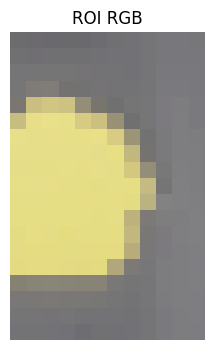

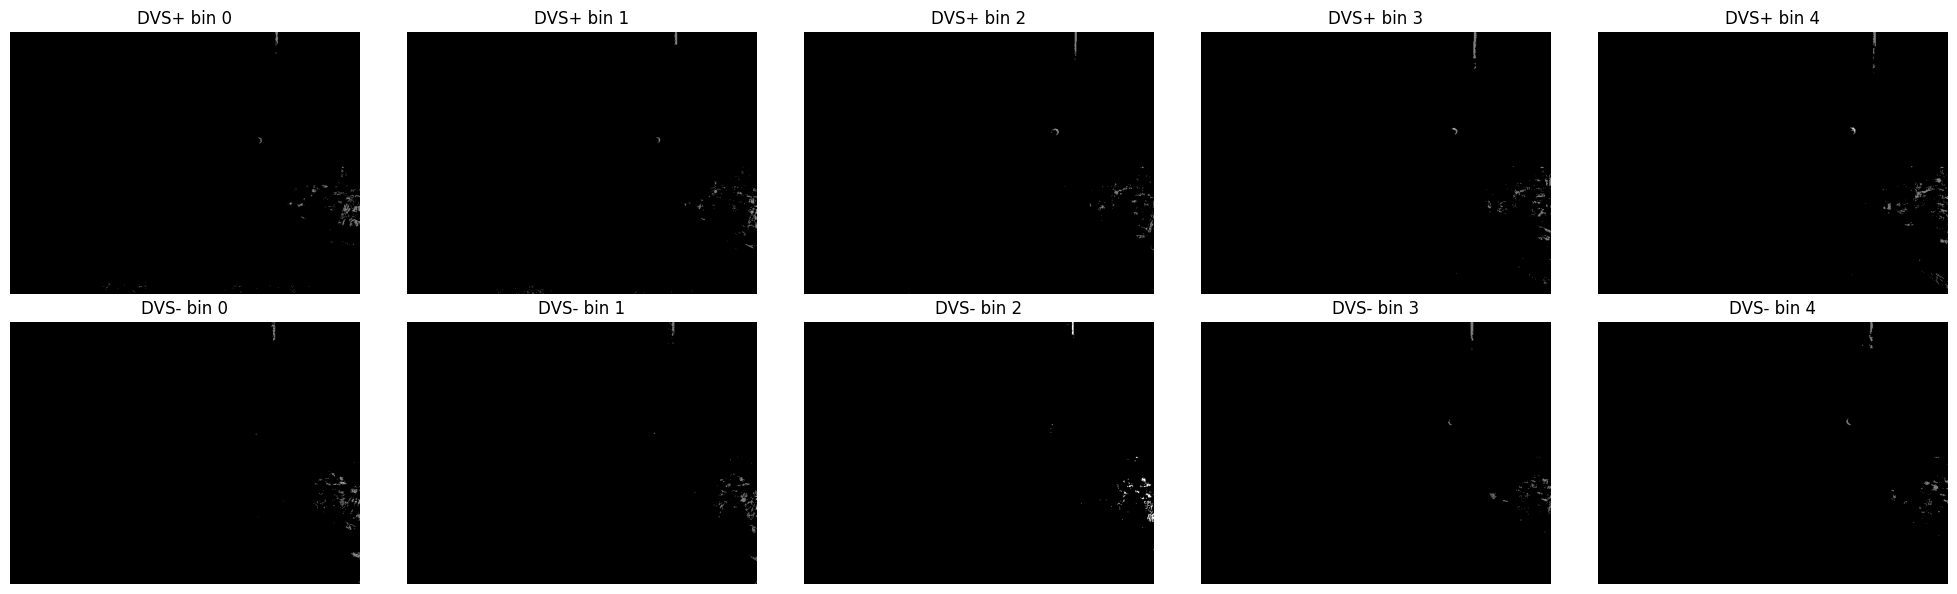

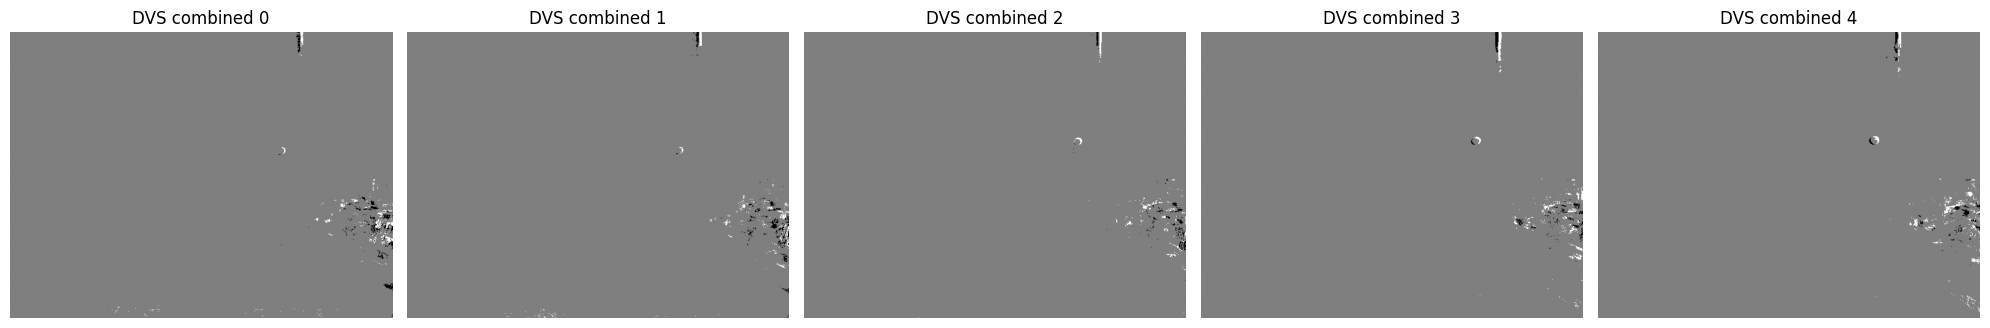

In [4]:
import json
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# CHANGE THIS
ROOT = Path("/kaggle/input/datasets/hussamsyed/dataset-400/dataset_400")

meta_files = list(ROOT.rglob("meta.json"))
print("meta files:", len(meta_files))

meta_path = random.choice(meta_files)
print("sample:", meta_path)

with open(meta_path, "r") as f:
    meta = json.load(f)

print("start_state:", meta.get("start_state"))
print("end_state:", meta.get("end_state"))
print("transition_label:", f"{meta.get('start_state')}_to_{meta.get('end_state')}")
print("quality_ok:", meta.get("quality_ok"))
print("bbox_refined_xyxy:", meta.get("bbox_refined_xyxy"))

sample_dir = meta_path.parent

rgb_path = sample_dir / "roi_rgb.png"
dvs_path = sample_dir / "dvs_sequence.npy"

rgb = np.array(Image.open(rgb_path).convert("RGB"))
dvs_seq = np.load(dvs_path)   # expected [T, 2, H, W]

print("roi_rgb shape:", rgb.shape)
print("dvs_sequence shape:", dvs_seq.shape)

# --------------------------
# Show RGB crop
# --------------------------
plt.figure(figsize=(4, 4))
plt.imshow(rgb)
plt.title("ROI RGB")
plt.axis("off")
plt.show()

# --------------------------
# Show DVS positive/negative channels
# --------------------------
T = dvs_seq.shape[0]

fig, axes = plt.subplots(2, T, figsize=(4*T, 6))
if T == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for i in range(T):
    pos = dvs_seq[i, 0]
    neg = dvs_seq[i, 1]

    axes[0, i].imshow(pos, cmap="gray")
    axes[0, i].set_title(f"DVS+ bin {i}")
    axes[0, i].axis("off")

    axes[1, i].imshow(neg, cmap="gray")
    axes[1, i].set_title(f"DVS- bin {i}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

# --------------------------
# Combined DVS visualization
# --------------------------
fig, axes = plt.subplots(1, T, figsize=(4*T, 4))
if T == 1:
    axes = [axes]

for i in range(T):
    pos = dvs_seq[i, 0]
    neg = dvs_seq[i, 1]

    vis = np.full(pos.shape, 127, dtype=np.uint8)
    vis[pos > 0] = 255
    vis[neg > 0] = 0

    axes[i].imshow(vis, cmap="gray")
    axes[i].set_title(f"DVS combined {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()